In [77]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import cross_val_score, GridSearchCV
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from statsmodels.tsa.stattools import adfuller

**1. Loading tesla_deliveries_dataset**  

Here we are loading the dataset into a dataFrame and performing several basic operations to understand its structure and contents.



In [78]:
df = pd.read_csv('tesla_deliveries_dataset_2015_2025.csv')
print("Shape:",df.shape)
print("Columns:",df.columns.tolist())
df.info()
df.describe()

Shape: (2640, 12)
Columns: ['Year', 'Month', 'Region', 'Model', 'Estimated_Deliveries', 'Production_Units', 'Avg_Price_USD', 'Battery_Capacity_kWh', 'Range_km', 'CO2_Saved_tons', 'Source_Type', 'Charging_Stations']
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2640 entries, 0 to 2639
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Year                  2640 non-null   int64  
 1   Month                 2640 non-null   int64  
 2   Region                2640 non-null   object 
 3   Model                 2640 non-null   object 
 4   Estimated_Deliveries  2640 non-null   int64  
 5   Production_Units      2640 non-null   int64  
 6   Avg_Price_USD         2640 non-null   float64
 7   Battery_Capacity_kWh  2640 non-null   int64  
 8   Range_km              2640 non-null   int64  
 9   CO2_Saved_tons        2640 non-null   float64
 10  Source_Type           2640 non-null   object 
 11  Charging_S

,Year,Month,Estimated_Deliveries,Production_Units,Avg_Price_USD,Battery_Capacity_kWh,Range_km,CO2_Saved_tons,Charging_Stations
count,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000
mean,2020.000000,6.500000,9922.199621,10655.847348,84907.340330,87.059470,500.257576,744.076989,8932.133712
std,3.162877,3.452707,3935.950093,4260.600858,20123.258036,20.836265,120.868549,353.221224,3469.565883
min,2015.000000,1.000000,48.000000,50.000000,50003.700000,60.000000,330.000000,3.070000,3002.000000
25%,2017.000000,3.750000,7292.000000,7828.250000,67726.365000,75.000000,418.000000,499.620000,5897.750000
50%,2020.000000,6.500000,9857.000000,10546.500000,85058.510000,82.000000,470.000000,699.515000,8901.500000
75%,2023.000000,9.250000,12510.250000,13469.000000,102373.042500,100.000000,586.250000,943.765000,11938.000000
max,2025.000000,12.000000,25704.000000,28939.000000,119965.360000,120.000000,719.000000,2548.550000,14996.000000


**2. Checking for missing values and duplicate rows**  

Here we are trying to identify missing values and duplicates, clean the dataset by removing duplicate rows, reset the index and check the updated dataset size.

In [79]:
print("Missing values per column:")
print(df.isnull().sum())
print("Duplicate rows:",df.duplicated().sum())
df.drop_duplicates(inplace=True)
print("After cleaning—Shape:",df.shape)

Missing values per column:
Year                    0
Month                   0
Region                  0
Model                   0
Estimated_Deliveries    0
Production_Units        0
Avg_Price_USD           0
Battery_Capacity_kWh    0
Range_km                0
CO2_Saved_tons          0
Source_Type             0
Charging_Stations       0
dtype: int64
Duplicate rows: 0
After cleaning—Shape: (2640, 12)


**3. Exploratory Data Analysis (EDA)**  

Here we are performing EDA by creating five different visualizations to understand the dataset. These charts help in examining correlations between numerical features and exploring the relationship between production and deliveries.

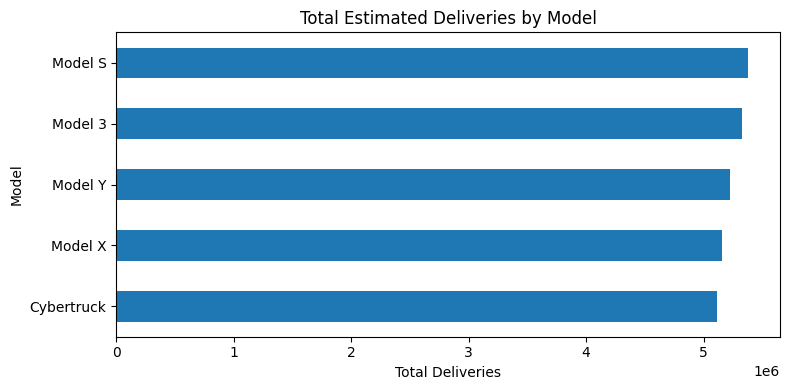

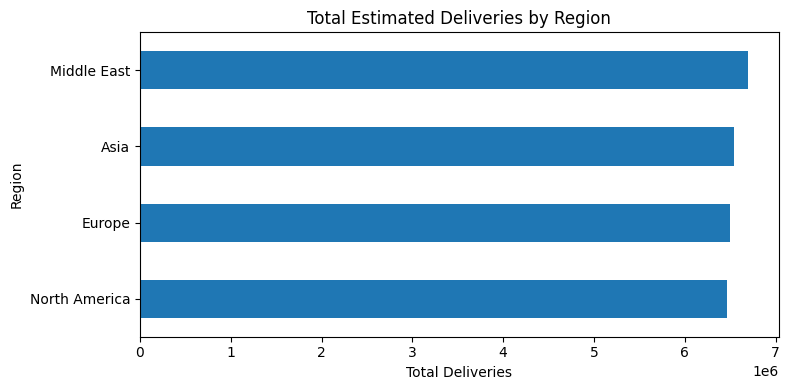

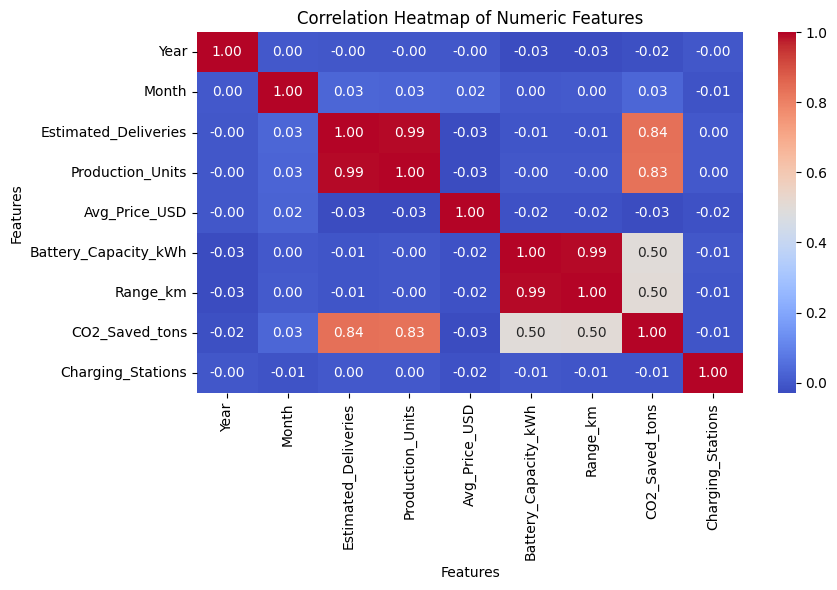

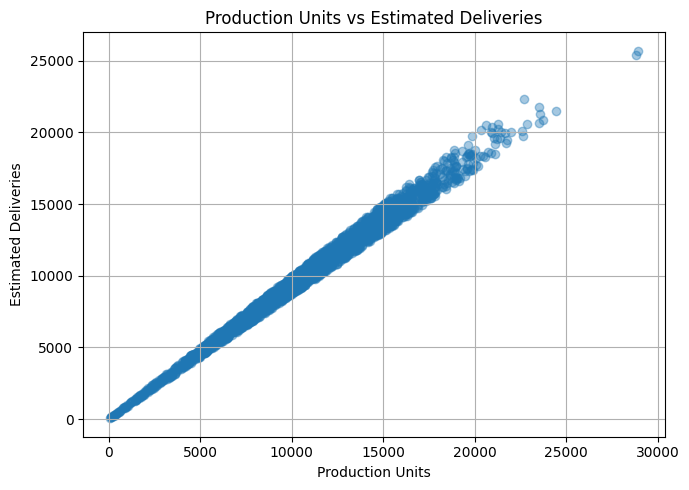

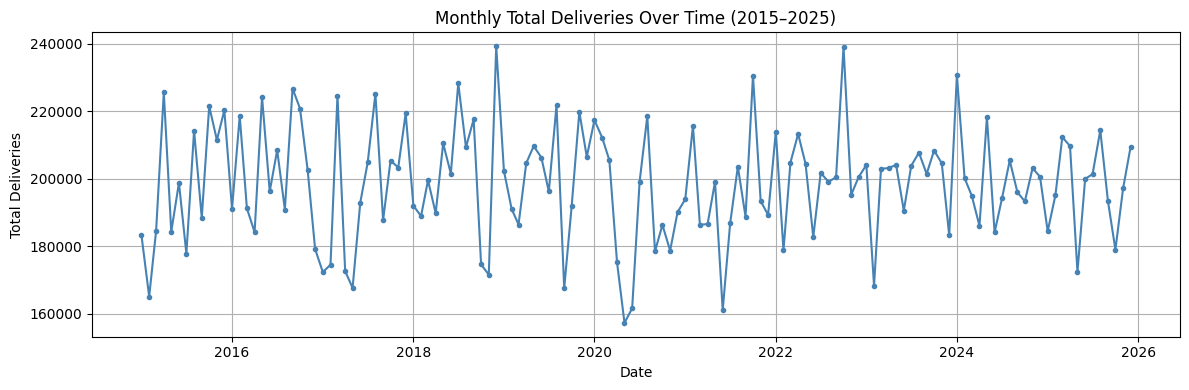

In [80]:
# Chart 1: Deliveries by Model
plt.figure(figsize=(8,4))
df.groupby('Model')['Estimated_Deliveries'].sum().sort_values().plot(kind='barh')
plt.title('Total Estimated Deliveries by Model')
plt.xlabel('Total Deliveries')
plt.ylabel('Model')
plt.tight_layout()
plt.show()
print()

# Chart 2: Deliveries by Region
plt.figure(figsize=(8,4))
df.groupby('Region')['Estimated_Deliveries'].sum().sort_values().plot(kind='barh')
plt.title('Total Estimated Deliveries by Region')
plt.xlabel('Total Deliveries')
plt.ylabel('Region')
plt.tight_layout()
plt.show()
print()

# Chart 3: Correlation Heatmap
plt.figure(figsize=(9,6))
sns.heatmap(df.select_dtypes(include='number').corr(), annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Correlation Heatmap of Numeric Features')
plt.xlabel('Features')
plt.ylabel('Features')
plt.tight_layout()
plt.show()
print()

# Chart 4: Production vs Deliveries Scatter
plt.figure(figsize=(7,5))
plt.scatter(df['Production_Units'], df['Estimated_Deliveries'], alpha=0.4)
plt.title('Production Units vs Estimated Deliveries')
plt.xlabel('Production Units')
plt.ylabel('Estimated Deliveries')
plt.grid(True)
plt.tight_layout()
plt.show()
print()
# Chart 5: Time-trend line
df['date'] = pd.to_datetime(df[['Year','Month']].assign(day=1))
monthly = df.groupby('date')['Estimated_Deliveries'].sum().sort_index()
plt.figure(figsize=(12,4))
plt.plot(monthly.index, monthly.values, color='steelblue', marker='o', markersize=3)
plt.title('Monthly Total Deliveries Over Time (2015–2025)')
plt.xlabel('Date')
plt.ylabel('Total Deliveries')
plt.grid(True)
plt.tight_layout()
plt.show()

**4. Feature Engineering**  

Here we are performing feature engineering by encoding categorical variables, creating lag and rolling mean features, handling the resulting missing values and verifying that the new features are free of missing values.

In [81]:
import warnings
warnings.filterwarnings('ignore')
le=LabelEncoder()
df['Region_enc']=le.fit_transform(df['Region'])
df['Model_enc']=le.fit_transform(df['Model'])
df['Source_Type_enc']=le.fit_transform(df['Source_Type'])
df['Deliveries_Lag1']=df['Estimated_Deliveries'].shift(1)
df['Deliveries_Lag1'].fillna(df['Deliveries_Lag1'].mean(), inplace=True)
df['Rolling_Mean_3']=df['Estimated_Deliveries'].rolling(3).mean()
df['Rolling_Mean_3'].fillna(df['Rolling_Mean_3'].mean(), inplace=True)

# Verifying no NaNs remain
print("NaNs in Deliveries_Lag1:",df['Deliveries_Lag1'].isnull().sum())
print("NaNs in Rolling_Mean_3:",df['Rolling_Mean_3'].isnull().sum())
print("Shape after engineering:",df.shape)

NaNs in Deliveries_Lag1: 0
NaNs in Rolling_Mean_3: 0
Shape after engineering: (2640, 18)


**5. Chronological Split and Linear Regression**  

Here we are preparing the data for model training, train a LR model, evaluate its performance using standard regression metrics and visualize the comparison between actual and predicted deliveries.

Train: 2112 rows (80.0%)
Test:528 rows (20.0%)
Linear Regression Results:
MAE:310.27020436816616
RMSE:375.43070908628914
R²:0.9908


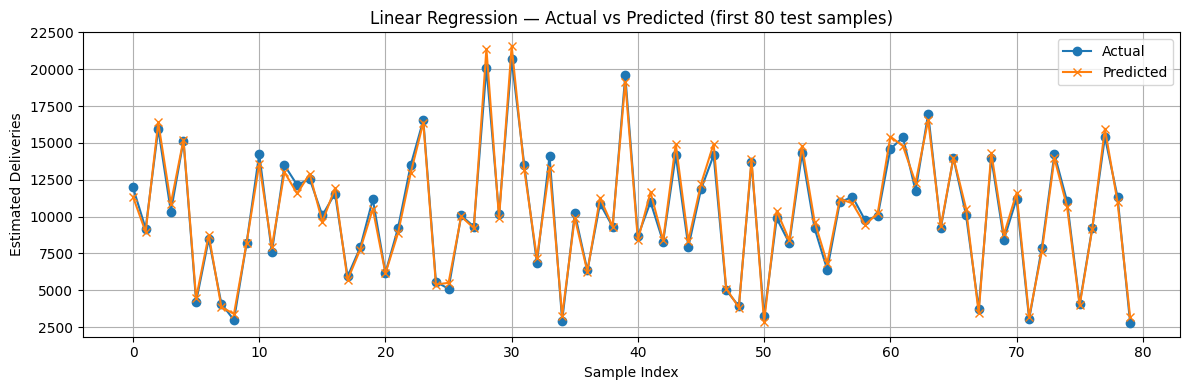

In [82]:
FEATURES=[
    'Production_Units', 'Avg_Price_USD', 'Battery_Capacity_kWh',
    'Range_km', 'CO2_Saved_tons', 'Charging_Stations',
    'Region_enc', 'Model_enc', 'Source_Type_enc',
    'Deliveries_Lag1', 'Rolling_Mean_3'
]
TARGET='Estimated_Deliveries'

X=df[FEATURES].values
y=df[TARGET].values

split=int(len(df)*0.8)
X_train,X_test=X[:split],X[split:]
y_train,y_test=y[:split],y[split:]

print(f"Train: {len(X_train)} rows ({len(X_train)/len(df)*100}%)")
print(f"Test:{len(X_test)} rows ({len(X_test)/len(df)*100}%)")

lr=LinearRegression()
lr.fit(X_train, y_train)
y_pred_lr=lr.predict(X_test)

lr_mae=mean_absolute_error(y_test,y_pred_lr)
lr_rmse=np.sqrt(mean_squared_error(y_test,y_pred_lr))
lr_r2=r2_score(y_test,y_pred_lr)

print(f"Linear Regression Results:")
print(f"MAE:{lr_mae}")
print(f"RMSE:{lr_rmse}")
print(f"R²:{lr_r2:.4f}")

# Actual vs Predicted plot
plt.figure(figsize=(12,4))
plt.plot(y_test[:80],label='Actual',marker='o')
plt.plot(y_pred_lr[:80],label='Predicted',marker='x')
plt.title('Linear Regression — Actual vs Predicted (first 80 test samples)')
plt.xlabel('Sample Index')
plt.ylabel('Estimated Deliveries')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

**6. 5-fold cross validation**  

Here we are performing 5-fold cross validation on the LR model to evaluate its performance across different data splits and calculate the mean and standard deviation of the R square scores.

In [83]:
cv_scores = cross_val_score(LinearRegression(), X_train, y_train, cv=5, scoring='r2')
for i, score in enumerate(cv_scores, 1):
    print(f"Fold {i}:R² = {score:.4f}")

print(f"Mean CV R²:{cv_scores.mean()}")
print(f"Std Dev:{cv_scores.std()}")

Fold 1:R² = 0.9908
Fold 2:R² = 0.9901
Fold 3:R² = 0.9905
Fold 4:R² = 0.9890
Fold 5:R² = 0.9909
Mean CV R²:0.9902652393237723
Std Dev:0.0006720176185697134


**7. GridSearchCV - Random Forest**  

Here we are using Grid Search with cross validation to find the best hyperparameters for the Random Forest model, evaluate its performance using regression metrics and visualize the top 10 most important features influencing the predictions.  

Best params: {'max_depth': None, 'n_estimators': 100}

Random Forest (Tuned) Results:
MAE:295.81
RMSE:375.46
R²:0.99


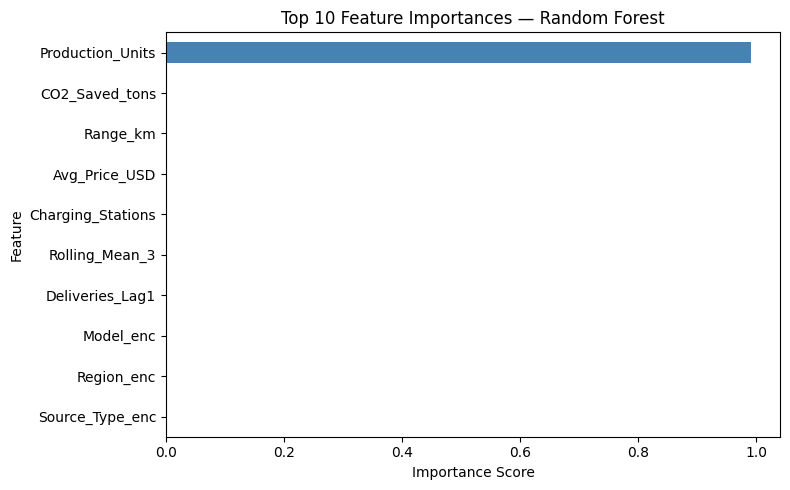

In [84]:
param_grid = {
    'n_estimators': [50, 100],
    'max_depth':    [5, 10, None]
}
grid = GridSearchCV(
    RandomForestRegressor(random_state=42),
    param_grid, cv=5, scoring='r2', n_jobs=-1
)
grid.fit(X_train,y_train)

print("Best params:",grid.best_params_)

best_rf= grid.best_estimator_
y_pred_rf=best_rf.predict(X_test)

rf_mae=mean_absolute_error(y_test,y_pred_rf)
rf_rmse=np.sqrt(mean_squared_error(y_test,y_pred_rf))
rf_r2=r2_score(y_test,y_pred_rf)

print(f"\nRandom Forest (Tuned) Results:")
print(f"MAE:{rf_mae:,.2f}")
print(f"RMSE:{rf_rmse:,.2f}")
print(f"R²:{rf_r2:.2f}")

# Top 10 Feature Importances
importances=pd.Series(best_rf.feature_importances_,index=FEATURES)
top10=importances.sort_values(ascending=True).tail(10)

plt.figure(figsize=(8,5))
top10.plot(kind='barh',color='steelblue')
plt.title('Top 10 Feature Importances — Random Forest')
plt.xlabel('Importance Score')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

**Random Forest scored about the same as LR i.e. R square = 0.99 for both. This is because Production_Units is almost perfectly correlated with Estimated_Deliveries.So the relationship is basically a straight line which means there isn't any extra pattern left for Random Forest to find.**

**8. ADF Stationarity Test**  

Here, we perform the ADF test to check whether the delivery time series is stationary. Based on the p-value, we determine if differencing is required before applying the ARIMA model.

In [85]:
result = adfuller(df['Estimated_Deliveries'].values, autolag='AIC')
print("ADF Stationarity Test — Estimated_Deliveries")
print(f"ADF Statistic:{result[0]:.4f}")
print(f"p-value:{result[1]:.4f}")
print(f"Lags used:{result[2]}")
print(f"Observations:{result[3]}")
for k,v in result[4].items():
    print(f"Critical ({k}):{v:.4f}")

print("Interpretation:")
if result[1]<0.05:
    print("p-value<0.05 → Reject null hypothesis.")
    print("The series is STATIONARY.")
    print("ARIMA can be applied directly without differencing.")
else:
    print("p-value>=0.05 → Fail to reject null hypothesis.")
    print("The series is NON-STATIONARY.")
    print("Differencing (d≥1) is recommended before applying ARIMA.")

ADF Stationarity Test — Estimated_Deliveries
ADF Statistic:-53.8266
p-value:0.0000
Lags used:0
Observations:2639
Critical (1%):-3.4328
Critical (5%):-2.8626
Critical (10%):-2.5674
Interpretation:
p-value<0.05 → Reject null hypothesis.
The series is STATIONARY.
ARIMA can be applied directly without differencing.


**9. Model Comparision and Forecast Table**  

Here we are comparing the performance of LR and Random Forest models using regression metrics. We also create a forecast table to compare the actual and predicted delivery values for the first 20 test records and calculate the prediction error percentage.

In [86]:
#Model Comparison Table
comparison_models=pd.DataFrame({
    'Model':['Linear Regression','Random Forest(Tuned)'],
    'MAE':[round(lr_mae,2),round(rf_mae,2)],
    'RMSE':[round(lr_rmse,2),round(rf_rmse,2)],
    'R²':[round(lr_r2,4),round(rf_r2,4)]
})
print("Model Comparison Table")
print(comparison_models.to_string(index=False))

#Forecast Table — first 20 test records
forecast_table=pd.DataFrame({
    'Actual':y_test[:20].astype(int),
    'Predicted':y_pred_rf[:20].round(0).astype(int),
})
forecast_table['Error']=forecast_table['Actual']-forecast_table['Predicted']
forecast_table['Error_%']=((forecast_table['Error'].abs()/forecast_table['Actual'])*100).round(2)
print("Forecast Table — First 20 Test Records")
print(forecast_table.to_string())
print(f"Mean Error %:{forecast_table['Error_%'].mean():.2f}%")

Model Comparison Table
               Model    MAE   RMSE     R²
   Linear Regression 310.27 375.43 0.9908
Random Forest(Tuned) 295.81 375.46 0.9908
Forecast Table — First 20 Test Records
    Actual  Predicted  Error  Error_%
0    11974      11298    676     5.65
1     9189       9042    147     1.60
2    15956      16716   -760     4.76
3    10336      10964   -628     6.08
4    15152      15677   -525     3.46
5     4224       4034    190     4.50
6     8475       8851   -376     4.44
7     4093       3831    262     6.40
8     2972       3124   -152     5.11
9     8208       8147     61     0.74
10   14260      13947    313     2.19
11    7570       7848   -278     3.67
12   13486      13327    159     1.18
13   12149      11580    569     4.68
14   12547      13066   -519     4.14
15   10084       9817    267     2.65
16   11566      11870   -304     2.63
17    5933       5702    231     3.89
18    7909       7876     33     0.42
19   11172      10471    701     6.27
Mean Error %:3